# Corpus Masterclass 1: A First Look at the State of the Union Corpus

Each code cell below is one teaching beat. Press **Shift+Enter** to run it.

## Today's goal

1. Load every State of the Union address (1790 to 2026) into a pandas DataFrame.
2. Look at individual speeches; summarise the metadata.
3. Plot speech length across two centuries, coloured by party.
4. Build a document-feature matrix: counts of every word in every speech.
5. Draw a word cloud of the most frequent corpus-wide terms.
6. Discover hidden topics with Latent Dirichlet Allocation.
7. Find each speech's most distinctive words.
8. Draw hierarchical-clustering dendrograms; vary the metric and the time slice.
9. Compare word clouds across presidential eras.

In [1]:
# Libraries used throughout the notebook.
import sotu
import pandas
import numpy
import matplotlib.pyplot as plt
import sklearn.feature_extraction.text
import sklearn.decomposition
import scipy.spatial.distance
import scipy.cluster.hierarchy
import wordcloud
import nltk.stem
from corpus_tools import comparison_cloud

print('Libraries imported.')

Libraries imported.


In [2]:
# The sotu library exposes every U.S. State of the Union address from 1790 to 2026 as a
# pandas DataFrame. Each row is one speech.
df = sotu.load()
print(f'{len(df)} speeches, {df["year"].min()} to {df["year"].max()}.')
df[['year', 'president', 'party', 'sotu_type']].head(3)

237 speeches, 1790 to 2026.


,year,president,party,sotu_type
0,1790,Washington,Nonpartisan,spoken
1,1790,Washington,Nonpartisan,spoken
2,1791,Washington,Nonpartisan,spoken


In [3]:
# Same data, the most recent few addresses.
df[['year', 'president', 'party', 'sotu_type']].tail(3)

,year,president,party,sotu_type
234,2023,Biden,Democratic,spoken
235,2024,Biden,Democratic,spoken
236,2026,Trump,Republican,spoken


In [4]:
# Washington's first address. The text column holds the full speech as a single string.
first = df.iloc[0]
print(f'{first["year"]} {first["president"]}')
print(first['text'][:600] + ' ...')

1790 Washington
Fellow-Citizens of the Senate and House of Representatives:

I embrace with great satisfaction the opportunity which now presents itself of congratulating you on the present favorable prospects of our public affairs. The recent accession of the important state of North Carolina to the Constitution of the United States (of which official information has been received), the rising credit and respectability of our country, the general and increasing good will toward the government of the Union, and the concord, peace, and plenty with which we are blessed are circumstances auspicious in an eminent ...


In [5]:
# Washington's second address.
second = df.iloc[1]
print(f'{second["year"]} {second["president"]}')
print(second['text'][:600] + ' ...')

1790 Washington
Fellow-Citizens of the Senate and House of Representatives:

In meeting you again I feel much satisfaction in being able to repeat my congratulations on the favorable prospects which continue to distinguish our public affairs. The abundant fruits of another year have blessed our country with plenty and with the means of a flourishing commerce.

The progress of public credit is witnessed by a considerable rise of American stock abroad as well as at home, and the revenues allotted for this and other national purposes have been productive beyond the calculations by which they were regulated. This ...


In [6]:
# Metadata at a glance: column names and types.
df.dtypes

year          int64
president    object
party        object
sotu_type    object
text         object
dtype: object

In [7]:
# How many speeches per party.
df['party'].value_counts()

party
Democratic               93
Republican               92
Democratic-Republican    28
Whig                      8
Nonpartisan               8
Federalist                4
National Union            4
Name: count, dtype: int64

In [8]:
# Speech length per address: tokens approximated by whitespace splitting.
df['tokens'] = df['text'].str.split().str.len()
df[['year', 'president', 'tokens']].head(5)

,year,president,tokens
0,1790,Washington,1090
1,1790,Washington,1408
2,1791,Washington,2146
3,1792,Washington,2098
4,1793,Washington,1965


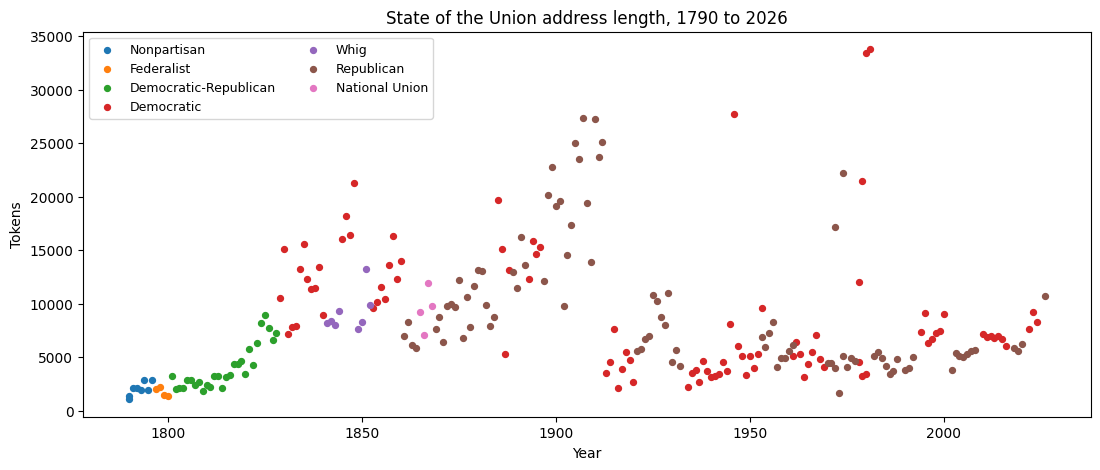

In [9]:
# Length across two centuries, one point per speech, coloured by party. The speeches
# are separate events, so we draw points and no line between them. A line would slope
# across the years between two addresses and imply measurements nobody took.
plt.figure(figsize=(13, 5))
for party in df['party'].unique():
    party_speeches = df[df['party'] == party]
    plt.scatter(party_speeches['year'], party_speeches['tokens'], s=18, label=party)
plt.xlabel('Year')
plt.ylabel('Tokens')
plt.title('State of the Union address length, 1790 to 2026')
plt.legend(loc='upper left', fontsize=9, ncol=2)
plt.show()

In [10]:
# A document-feature matrix (DFM) holds the count of every word in every document.
# sklearn.feature_extraction.text.CountVectorizer builds it in one call, with English
# stop-word removal built in.
vectorizer = sklearn.feature_extraction.text.CountVectorizer(
    lowercase=True,
    stop_words='english',
)
dfm = vectorizer.fit_transform(df['text'])
features = vectorizer.get_feature_names_out()
labels = (df['year'].astype(str) + ' ' + df['president']).tolist()

print(f'DFM: {dfm.shape[0]} speeches by {dfm.shape[1]} unique features.')

DFM: 237 speeches by 26013 unique features.


In [11]:
# Top 20 features across the whole corpus.
dfm_df = pandas.DataFrame(dfm.toarray(), index=labels, columns=features)
corpus_totals = dfm_df.sum(axis=0).sort_values(ascending=False)
corpus_totals.head(20)

government    7629
states        6948
congress      5821
united        5170
year          4839
people        4458
country       3727
new           3534
great         3494
public        3408
000           3218
time          3180
american      3014
war           2952
world         2842
years         2725
national      2428
nation        2395
state         2375
law           2366
dtype: int64

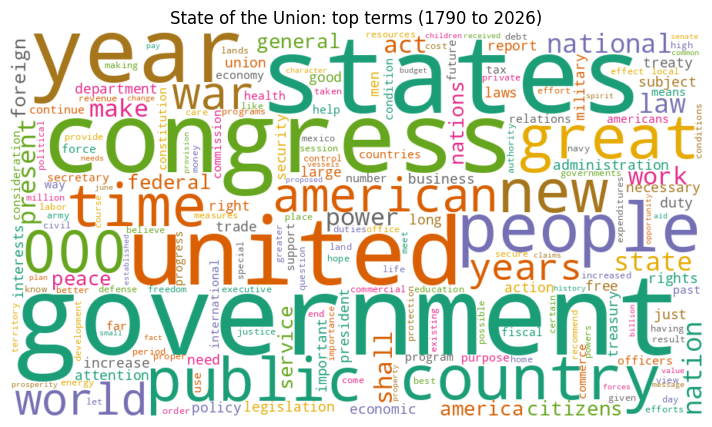

In [12]:
# Word cloud of the corpus-wide top terms.
wc = wordcloud.WordCloud(
    width=900,
    height=500,
    background_color='white',
    colormap='Dark2',
    random_state=42,
).generate_from_frequencies(corpus_totals.to_dict())

plt.figure(figsize=(10, 5))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title('State of the Union: top terms (1790 to 2026)')
plt.show()

In [13]:
# Why stem at all? In the unstemmed matrix every word form is its own feature, so a
# single idea is split across many columns. The variants of 'nation' below each carry a
# separate count, and stemming rewrites them to a shared root.
# NLTK stemmers: https://www.nltk.org/howto/stem.html
demo_stemmer = nltk.stem.SnowballStemmer('english')
nation_like = []
for word in features:
    if word.startswith('nation'):
        nation_like.append(word)

distinct_roots = []
for word in nation_like:
    root = demo_stemmer.stem(word)
    if root not in distinct_roots:
        distinct_roots.append(root)
    print(f'{word:16s} count {int(corpus_totals[word]):5d}   ->  {root}')

print(f'{len(nation_like)} separate features reduce to {len(distinct_roots)} root(s) after stemming.')

nation           count  2395   ->  nation
national         count  2428   ->  nation
nationalism      count     6   ->  nation
nationalist      count     4   ->  nationalist
nationalities    count     9   ->  nation
nationality      count    19   ->  nation
nationalized     count     2   ->  nation
nationalizes     count     1   ->  nation
nationally       count    10   ->  nation
nationals        count    16   ->  nation
nations          count  1955   ->  nation
nationwide       count    23   ->  nationwid
12 separate features reduce to 3 root(s) after stemming.


In [14]:
# Build the stemmed, trimmed matrix that the topic model and the dendrograms will use.
# Stemming merges the variants we just saw into one root. Trimming drops words too rare
# to carry clustering signal. The word cloud and top-feature lists above keep the full,
# unstemmed words.
stemmer = nltk.stem.SnowballStemmer('english')

def stem_text(text):
    roots = []
    for word in text.lower().split():
        roots.append(stemmer.stem(word))
    return ' '.join(roots)

stemmed_docs = []
for text in df['text']:
    stemmed_docs.append(stem_text(text))

stem_vectorizer = sklearn.feature_extraction.text.CountVectorizer(
    stop_words='english',
    min_df=3,
)
stem_counts = stem_vectorizer.fit_transform(stemmed_docs).toarray()
stem_features = stem_vectorizer.get_feature_names_out()

# The other half of dfm_trim: keep only words that occur at least 5 times in total.
column_totals = stem_counts.sum(axis=0)
keep = column_totals >= 5
stem_counts = stem_counts[:, keep]
stem_features = stem_features[keep]
print(f'Stemmed, trimmed: {stem_counts.shape[0]} speeches by {stem_counts.shape[1]} features.')

Stemmed, trimmed: 237 speeches by 10173 features.


In [15]:
# Latent Dirichlet Allocation finds clusters of words that tend to co-occur across
# documents. Each cluster is a topic; each speech is a mixture of topics.
# top_topics runs one model and lists each topic's leading words, tagged with the topic's
# document mass: how many speeches' worth of weight it carries. Written once and reused
# for both runs below.
def top_topics(model):
    document_mass = model.transform(stem_counts).sum(axis=0)
    topics = {}
    for topic_index, weights in enumerate(model.components_):
        top_indices = weights.argsort()[-10:][::-1]
        top_words = []
        for word_index in top_indices:
            top_words.append(stem_features[word_index])
        label = f'Topic {topic_index + 1} (mass {document_mass[topic_index]:.1f})'
        topics[label] = top_words
    return pandas.DataFrame(topics)

In [16]:
# Run it on the stemmed, trimmed matrix, so the topic words come out as roots. The number
# of topics is a choice. Start with eight, and read the mass tagged on each column.
# scikit-learn LDA: https://scikit-learn.org/stable/modules/decomposition.html#latent-dirichlet-allocation-lda
lda8 = sklearn.decomposition.LatentDirichletAllocation(
    n_components=8,
    random_state=42,
    max_iter=20,
).fit(stem_counts)
top_topics(lda8)

,Topic 1 (mass 24.5),Topic 2 (mass 40.1),Topic 3 (mass 17.4),Topic 4 (mass 99.1),Topic 5 (mass 17.0),Topic 6 (mass 0.0),Topic 7 (mass 0.0),Topic 8 (mass 38.8)
0,year,nation,000,state,law,consign,consign,america
1,program,world,year,unit,govern,license,license,american
2,nation,war,govern,govern,ani,wished,wished,year
3,feder,peopl,unit,congress,public,shelf,shelf,work
4,congress,great,dure,public,work,refut,refut,new
5,new,free,state,ani,state,1823,1823,peopl
6,increas,power,increas,great,great,directions,directions,make
7,continu,time,american,nation,congress,prestig,prestig,world
8,govern,peac,congress,power,nation,readiness,readiness,help
9,develop,onli,report,year,countri,judicial,judicial,nation


## Eight topics is too many

Two of these topics are identical and own almost no speeches. Eight topics is more than this corpus supports. The surplus topics find no documents, so they collapse onto the same handful of rare words. Choosing the number of topics is a real modelling decision.

Further reading: [scikit-learn's LDA guide](https://scikit-learn.org/stable/modules/decomposition.html#latent-dirichlet-allocation-lda) and [Wallach, Mimno & McCallum (2009), *Rethinking LDA: Why Priors Matter*](https://papers.nips.cc/paper/3854-rethinking-lda-why-priors-matter), which shows how better priors make topic models robust to this choice.

In [17]:
# Five topics. Every topic now owns real document weight and the duplicates are gone.
lda5 = sklearn.decomposition.LatentDirichletAllocation(
    n_components=5,
    random_state=42,
    max_iter=20,
).fit(stem_counts)
top_topics(lda5)

,Topic 1 (mass 37.4),Topic 2 (mass 51.9),Topic 3 (mass 25.4),Topic 4 (mass 98.3),Topic 5 (mass 23.9)
0,nation,american,000,state,nation
1,year,america,year,unit,ani
2,program,year,govern,govern,law
3,congress,peopl,state,congress,great
4,feder,world,unit,public,govern
5,new,new,congress,ani,men
6,world,work,law,great,onli
7,increas,nation,dure,nation,public
8,govern,make,increas,power,work
9,continu,everi,american,year,power


In [18]:
# Top 10 words for each of the first three individual speeches.
for row_index in range(3):
    top = dfm_df.iloc[row_index].sort_values(ascending=False).head(10)
    print(f'\n{labels[row_index]}:')
    for word, count in top.items():
        print(f'    {word}: {int(count)}')


1790 Washington:
    public: 5
    measures: 4
    states: 4
    end: 4
    great: 4
    united: 4
    country: 4
    government: 4
    regard: 4
    citizens: 3

1790 Washington:
    citizens: 5
    public: 5
    means: 4
    national: 4
    great: 4
    present: 4
    country: 4
    commerce: 4
    certain: 3
    house: 3

1791 Washington:
    united: 16
    states: 16
    public: 10
    proper: 7
    important: 7
    government: 7
    law: 6
    provision: 6
    measures: 6
    objects: 6


In [19]:
# Row-normalisation of the stemmed, trimmed matrix: divide each row by its total so long
# speeches do not dominate pairwise distances. After this every row sums to 1.
dfm_dense = stem_counts.astype(float)
row_totals = dfm_dense.sum(axis=1, keepdims=True)
row_totals[row_totals == 0] = 1.0
normalised = dfm_dense / row_totals
print(f'Row-sum range: {normalised.sum(axis=1).min():.3f} to {normalised.sum(axis=1).max():.3f}')

Row-sum range: 1.000 to 1.000


In [20]:
# Helper. Given a matrix slice and labels, draw the hierarchical-clustering
# dendrogram. The metric and title vary; everything else is the same.
def render_dendrogram(matrix, leaf_labels, metric, title, figsize=(14, 6), leaf_font_size=7):
    distances = scipy.spatial.distance.pdist(matrix, metric=metric)
    linkage = scipy.cluster.hierarchy.linkage(distances, method='complete')
    plt.figure(figsize=figsize)
    scipy.cluster.hierarchy.dendrogram(
        linkage,
        labels=leaf_labels,
        leaf_rotation=90,
        leaf_font_size=leaf_font_size,
    )
    plt.title(title)
    plt.show()

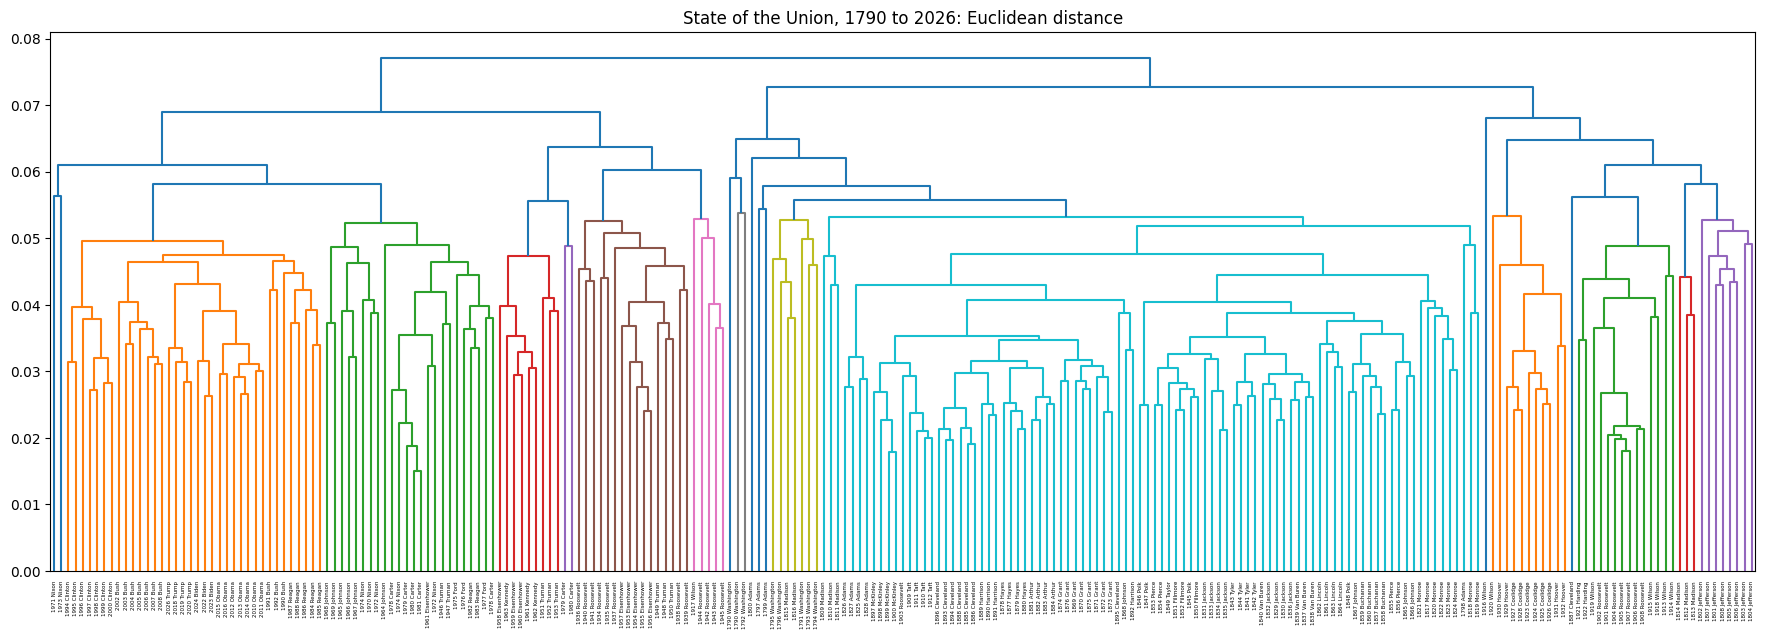

In [21]:
# Every speech, Euclidean distance. With 240+ leaves the labels are tiny; the shape
# of the tree is what matters at this scale.
render_dendrogram(
    normalised,
    labels,
    metric='euclidean',
    title='State of the Union, 1790 to 2026: Euclidean distance',
    figsize=(22, 7),
    leaf_font_size=4,
)

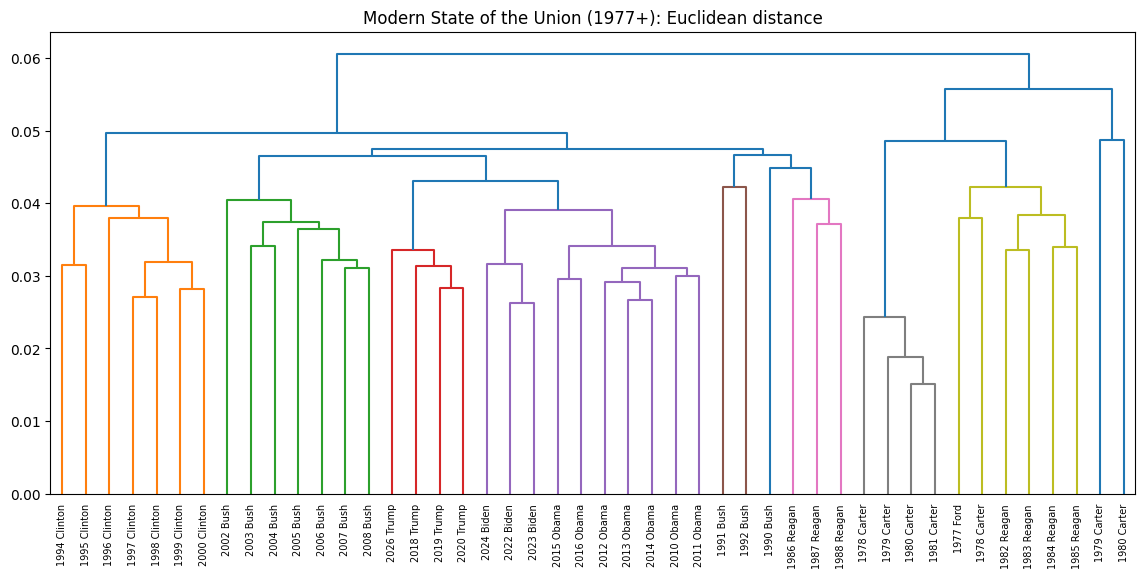

In [22]:
# Modern subset, Euclidean distance.
modern_mask = (df['year'] >= 1977).to_numpy()
modern_matrix = normalised[modern_mask]
modern_labels = []
for label, keep in zip(labels, modern_mask):
    if keep:
        modern_labels.append(label)

render_dendrogram(
    modern_matrix,
    modern_labels,
    metric='euclidean',
    title='Modern State of the Union (1977+): Euclidean distance',
)

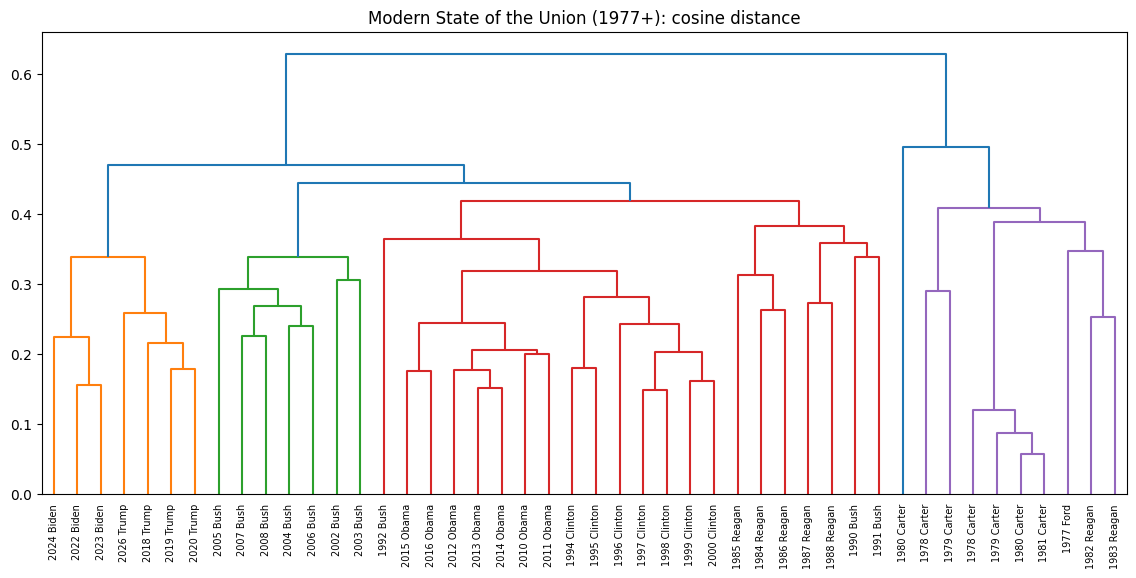

In [23]:
# Same modern subset, cosine distance. Cosine measures the angle between two count
# vectors and ignores their magnitude. scipy's 'cosine' metric is a true distance, one
# minus the cosine similarity, so the most similar speeches sit closest together.
render_dendrogram(
    modern_matrix,
    modern_labels,
    metric='cosine',
    title='Modern State of the Union (1977+): cosine distance',
)

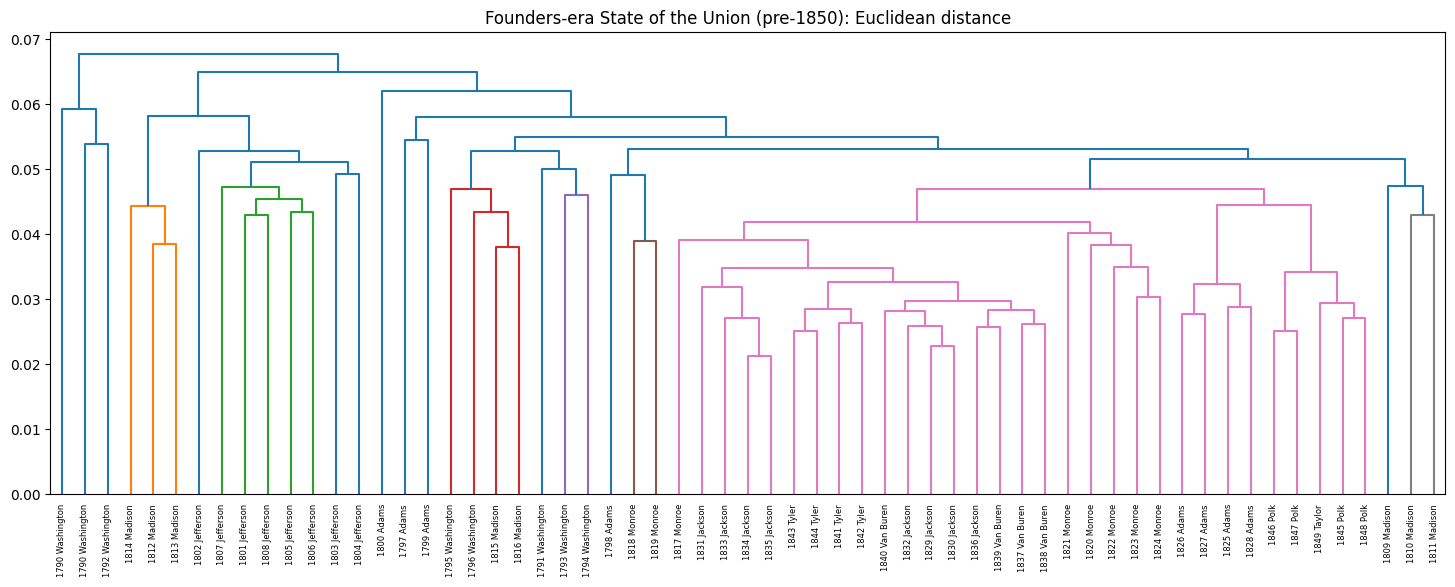

In [24]:
# Founders era, Euclidean distance.
founders_mask = (df['year'] < 1850).to_numpy()
founders_matrix = normalised[founders_mask]
founders_labels = []
for label, keep in zip(labels, founders_mask):
    if keep:
        founders_labels.append(label)

render_dendrogram(
    founders_matrix,
    founders_labels,
    metric='euclidean',
    title='Founders-era State of the Union (pre-1850): Euclidean distance',
    figsize=(18, 6),
    leaf_font_size=6,
)

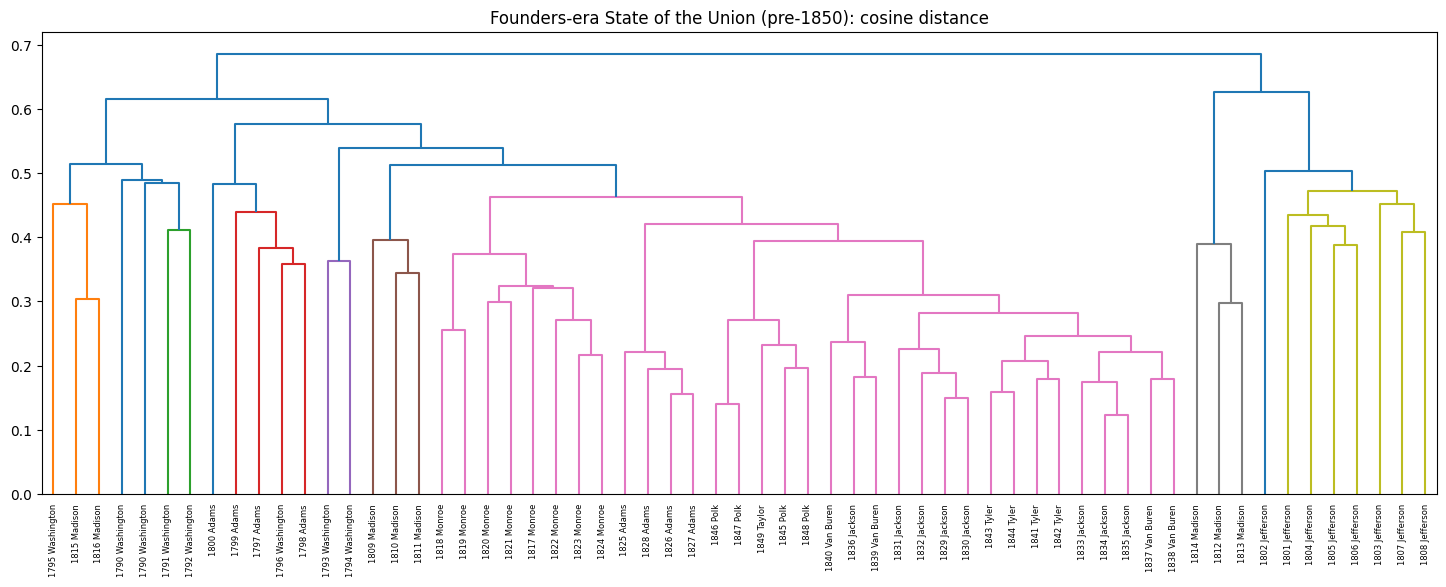

In [25]:
# Founders era, cosine distance. Compare the four dendrograms above and ask which
# pairs of speeches consistently cluster together regardless of metric and time slice.
render_dendrogram(
    founders_matrix,
    founders_labels,
    metric='cosine',
    title='Founders-era State of the Union (pre-1850): cosine distance',
    figsize=(18, 6),
    leaf_font_size=6,
)

In [26]:
# Helper for the comparison-wordcloud beats. comparison_cloud, imported from corpus_tools,
# draws the R-style wedge cloud. comparison_for picks each speaker's first few speeches and
# hands their document-feature rows to it. We select by name, not row number, so this keeps
# working as the corpus grows each year.
def comparison_for(speakers, per_speaker):
    chosen = []
    for name in speakers:
        taken = 0
        for position in range(len(df)):
            if df.iloc[position]['president'] == name:
                chosen.append(position)
                taken = taken + 1
                if taken >= per_speaker:
                    break
    labels = []
    for position in chosen:
        labels.append(f"{df.iloc[position]['president']}-{df.iloc[position]['year']}")
    comparison_cloud(dfm[chosen].toarray(), features, labels)

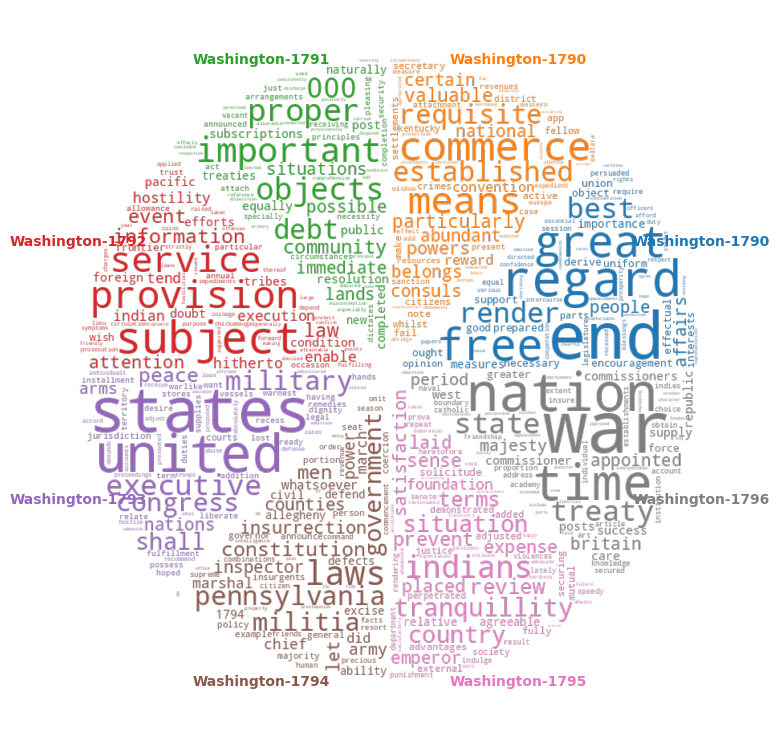

In [27]:
# Washington's eight messages: which words distinguish each from the others.
comparison_for(['Washington'], 8)

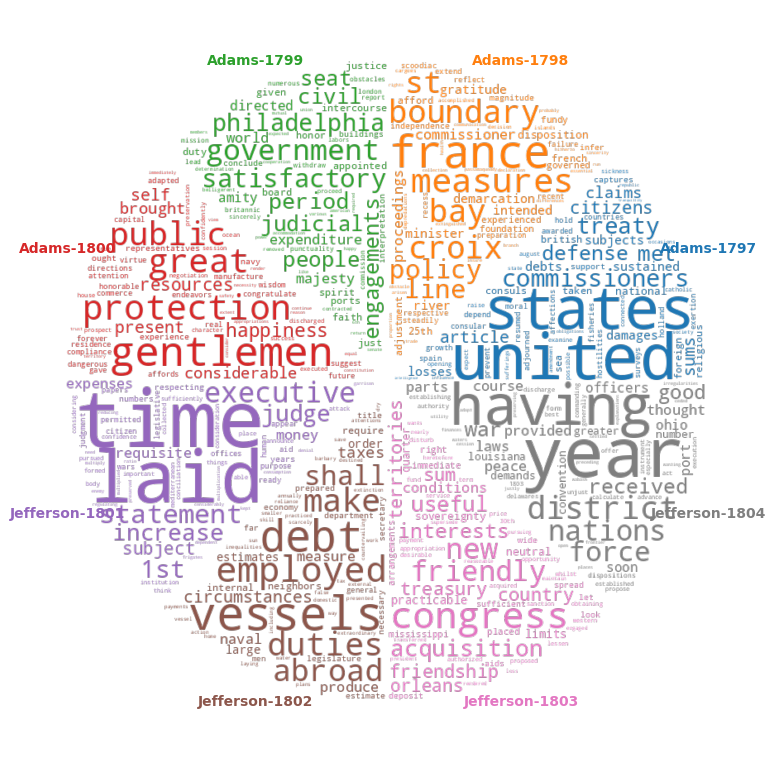

In [28]:
# Adams and Jefferson, four speeches each.
comparison_for(['Adams', 'Jefferson'], 4)

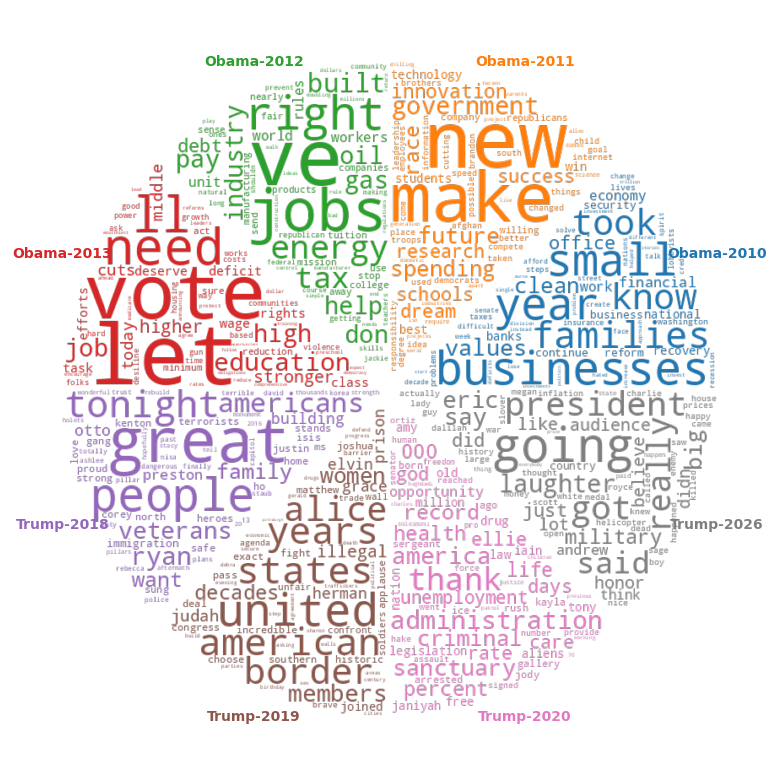

In [29]:
# Obama and Trump, four speeches each.
comparison_for(['Obama', 'Trump'], 4)

## What we've covered

**Python:** library imports, pandas DataFrame inspection and column assignment, boolean masking, `for` loops, defining functions with default arguments, f-strings, importing a helper from a local module.

**Corpus linguistics:** loading a built-in corpus; document-feature matrix; English stop-word filtering; corpus-wide vs per-document top features; word clouds; stemming to merge word variants; Latent Dirichlet Allocation for topic discovery and the effect of choosing the number of topics; hierarchical clustering with Euclidean and cosine distance; dendrograms; comparison word clouds across presidential eras.

## Read more

- **NLTK Book**, Chapter 1: [https://www.nltk.org/book/ch01.html](https://www.nltk.org/book/ch01.html).
- **scikit-learn user guide on text feature extraction**: [https://scikit-learn.org/stable/modules/feature_extraction.html](https://scikit-learn.org/stable/modules/feature_extraction.html).
- **scikit-learn user guide on Latent Dirichlet Allocation**: [https://scikit-learn.org/stable/modules/decomposition.html#latent-dirichlet-allocation-lda](https://scikit-learn.org/stable/modules/decomposition.html#latent-dirichlet-allocation-lda).
- **scipy hierarchical clustering**: [https://docs.scipy.org/doc/scipy/reference/cluster.hierarchy.html](https://docs.scipy.org/doc/scipy/reference/cluster.hierarchy.html).
- **matplotlib pyplot tutorial**: [https://matplotlib.org/stable/tutorials/pyplot.html](https://matplotlib.org/stable/tutorials/pyplot.html).
- **wordcloud README**: [https://github.com/amueller/word_cloud](https://github.com/amueller/word_cloud).
- **matplotlib named colormaps**: [https://matplotlib.org/stable/tutorials/colors/colormaps.html](https://matplotlib.org/stable/tutorials/colors/colormaps.html).